# 03 — Exploratory Data Analysis (EDA)
## DataCo Supply Chain — Late Delivery Risk Prediction

**Goal of this notebook:**
- Understand the distribution of late deliveries
- Discover which factors are most associated with late delivery
- Explore patterns across: Shipping Mode, Market, Customer Segment,
  Order Status, Department, and time features
- Build the visual story that supports our 4 tracks

**Input:**  data/cleaned_data.csv  

In [1]:
# ===========================================
# Imports
# ===========================================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

---
## Load Cleaned Data


In [2]:
df = pd.read_csv('../data/cleaned_data.csv')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Shape: 180519 rows x 28 columns


---
##  Target Distribution
How many orders are late vs on time?

This is the first and most important question.

In [3]:
# ===========================================
# TARGET DISTRIBUTION
# ===========================================

# Count how many orders are late (1) and on time (0)
total = len(df)

late    = (df['Late_delivery_risk'] == 1).sum()
on_time = (df['Late_delivery_risk'] == 0).sum()

late_pct    = round(late / total * 100, 1)
on_time_pct = round(on_time / total * 100, 1)

print(f"Total Orders : {total:,}")
print(f"On Time  (0) : {on_time:,} ({on_time_pct}%)")
print(f"Late     (1) : {late:,} ({late_pct}%)")


Total Orders : 180,519
On Time  (0) : 81,542 (45.2%)
Late     (1) : 98,977 (54.8%)


### Target Distribution — Insight

- 54.8% of orders are late — this confirms the business problem is significant
- 45.2% vs 54.8% — the dataset is relatively balanced
- No need for special imbalance handling techniques


---

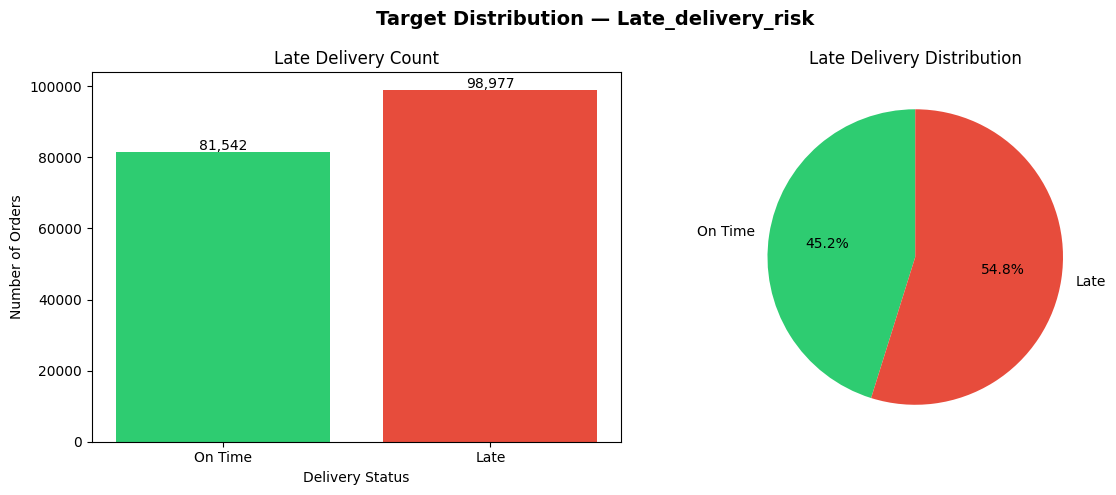

In [4]:
# ===========================================
# PLOT TARGET DISTRIBUTION
# ===========================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['On Time', 'Late'], 
            [on_time, late], 
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Late Delivery Count')
axes[0].set_ylabel('Number of Orders')
axes[0].set_xlabel('Delivery Status')

# Add numbers on top of bars
axes[0].text(0, on_time + 500, f'{on_time:,}', ha='center')
axes[0].text(1, late + 500,    f'{late:,}',    ha='center')

# Pie chart
axes[1].pie([on_time, late],
            labels=['On Time', 'Late'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Late Delivery Distribution')

plt.suptitle('Target Distribution — Late_delivery_risk', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/01_target_distribution.png', dpi=150)
plt.show()

---
## Late Delivery by Shipping Mode
Shipping Mode is expected to be one of the strongest predictors.

In [ ]:



shipping_late = (
    (df.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100)
      .round(1)
      .sort_values(ascending=False)
)

print("Late Rate by Shipping Mode:")
print("=" * 40)
for mode, rate in shipping_late.items():
    print(f"{mode:<20} : {rate:.1f}%")


Late Rate by Shipping Mode:
First Class          : 95.3%
Second Class         : 76.6%
Same Day             : 45.7%
Standard Class       : 38.1%


### Notes
First Class and Second Class shipping show the highest late delivery rates,
while Same Day and Standard Class have significantly lower rates. 
This may indicate that faster shipping options are more prone to delays 
due to stricter delivery time constraints.

---
## Late Rate by Market

In [9]:
# ===========================================
# Late Rate by Market
# ===========================================
market_late = (
    df.groupby('Market')['Late_delivery_risk']
      .mean()
      .mul(100)
      .round(1)
      .sort_values(ascending=False)
)

print("Late Rate by Market:")
print("="*40)

for market, rate in market_late.items():
    print(f"{market:20} : {rate}%")

Late Rate by Market:
Europe               : 55.2%
Pacific Asia         : 55.0%
USCA                 : 54.8%
Africa               : 54.6%
LATAM                : 54.4%


Late delivery rates are very similar across all markets (around 54–55%).

This indicates that geographic region does not significantly affect the
probability of late deliveries in the dataset.

---

## Sales vs Late Delivery

Do higher-value orders experience longer or shorter delays?

Using: Order Item Product Price

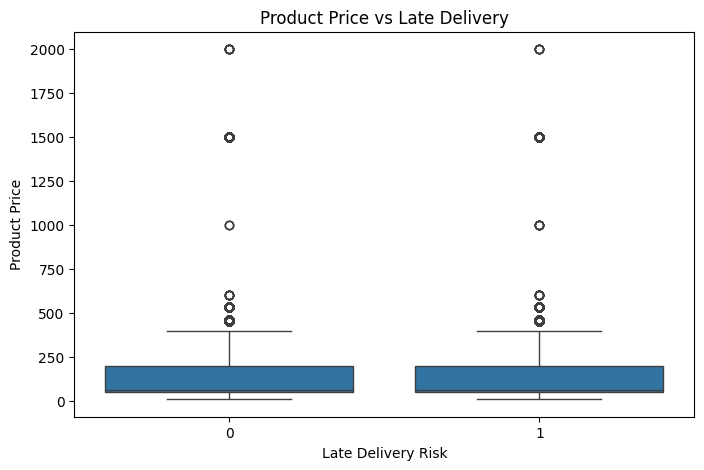

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Late_delivery_risk',
    y='Order Item Product Price',
    data=df
)

plt.title('Product Price vs Late Delivery')
plt.xlabel('Late Delivery Risk')
plt.ylabel('Product Price')

plt.show()

Interpretation: Product Price vs Late Delivery

The distribution of product prices appears similar for both late and on-time deliveries.
This suggests that product price alone may not strongly influence the likelihood of late delivery.

---

## Late Rate by Customer Segment

The purpose of this analysis is:

To determine if the customer segment affects the likelihood of order delays.

Using: Customer Segment

In [13]:
# ===========================================
# Late Rate by Customer Segment
# ===========================================

segment_late = (
    df.groupby('Customer Segment')['Late_delivery_risk']
      .mean()
      .mul(100)
      .round(1)
      .sort_values(ascending=False)
)

print("Late Rate by Customer Segment:")
print("="*40)

for segment, rate in segment_late.items():
    print(f"{segment:20} : {rate}%")

Late Rate by Customer Segment:
Home Office          : 55.1%
Consumer             : 54.8%
Corporate            : 54.7%


Late delivery rates are nearly identical across customer segments 
(~54–55%), suggesting that customer type does not strongly affect 
delivery delays in this dataset.

---
## Correlation Heatmap

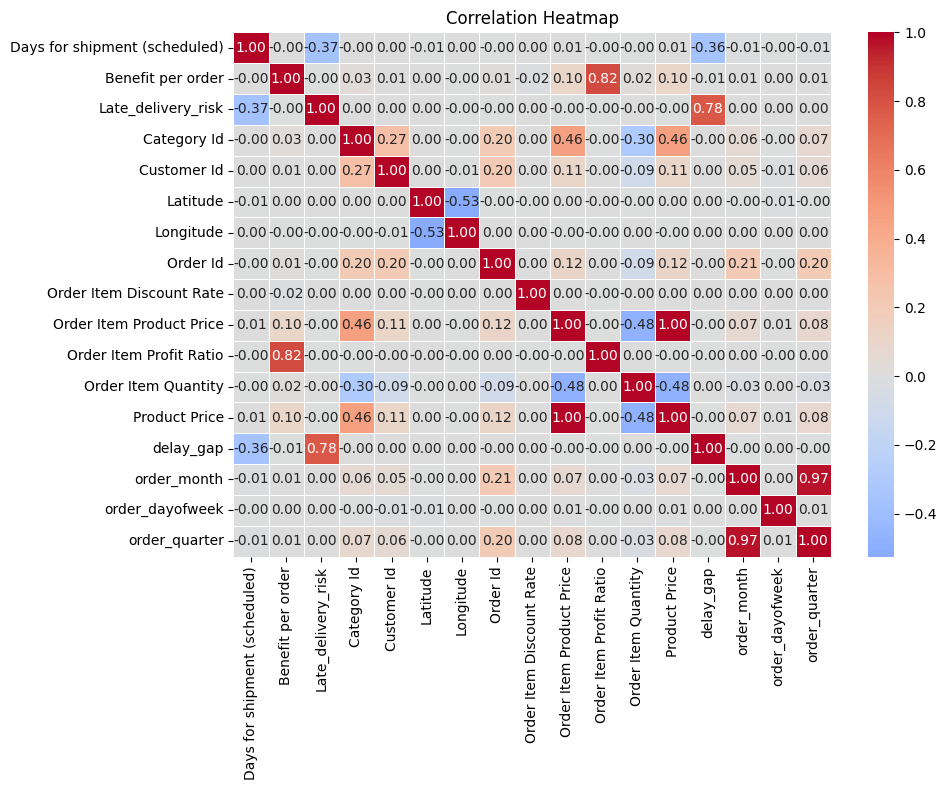

In [15]:
# ===========================================
# Correlation Heatmap
# ===========================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr, 
    cmap='coolwarm', 
    center=0, 
    annot=True,    
    fmt=".2f",     
    linewidths=0.5 
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

### Correlation Analysis Summary
 Based on the heatmap above, here are the key insights regarding the variables:

1. Key Drivers for Late_delivery_risk
Strong Positive Correlation (0.78): There is a high correlation with delay_gap. This confirms that the risk of late delivery is directly tied to the actual delay time experienced.

Negative Correlation (-0.37): A moderate inverse relationship exists with Days for shipment (scheduled). This suggests that tighter shipping schedules (fewer days) often lead to a higher risk of late delivery.

2. Significant Relationships Between Other Variables
Product Pricing (1.00): Product Price and Order Item Product Price are perfectly correlated, indicating they represent the same data. One can be dropped to reduce redundancy.

Profitability (0.82): A strong link exists between Benefit per order and Order Item Profit Ratio, showing that profit margins are the main driver of the overall benefit.

Time Hierarchy (0.97): order_month and order_quarter are almost perfectly correlated, which is expected as quarters are derived from months.

Inventory/Sales (-0.48): There is a moderate negative correlation between Order Item Quantity and Product Price, implying that more expensive items tend to be ordered in smaller quantities.

---
## Key Insights from EDA

1. **Shipping Mode is the strongest predictor** — but not in the expected direction.
   First Class has the highest late rate (95.3%) while Standard Class has the lowest (38.1%).
   This suggests the problem is unrealistic scheduled delivery promises,
   not actual shipping speed.

2. Market and Customer Segment show very similar late rates (~54-55%)
   across all categories — geography and customer type are not major factors.

3. The real driver of late delivery is the gap between promised
   and actual delivery days (delay_gap), not the shipping speed itself.

4. **Key Business Insight:** The solution is not to upgrade shipping methods,
   but to set more realistic delivery expectations for First Class orders.

---
## Next Steps — Modeling Tracks

The EDA is complete. The cleaned dataset is ready for modeling.
We will apply three analytical tracks in the following order:

**Track 1 — Supervised Classification** `04_track1_classification.ipynb`
- Business Question: Will this order be late?
- Target: `Late_delivery_risk` (0 = on time, 1 = late)
- Key Features: Shipping Mode, Days for shipment (scheduled), Category Name, Market
- Models: Logistic Regression (baseline) → Random Forest → XGBoost (tuned)
- Primary Metric: F1 Score + ROC AUC
- Key finding from EDA: Shipping Mode is the strongest predictor

**Track 2 — Supervised Regression** `05_track2_regression.ipynb`
- Business Question: How many days will the delay be?
- Target: `delay_gap` (real days − scheduled days), range: -2 to 4
- Key Features: Same as Track 1 excluding Late_delivery_risk
- Models: Linear Regression (baseline) → Random Forest Regressor → Gradient Boosting (tuned)
- Primary Metric: MAE + RMSE + R²
- Key finding from EDA: First Class has unrealistic scheduled dates — root cause of delays

**Track 3 — Unsupervised Clustering** `06_track3_clustering.ipynb`
- Business Question: What types of orders are most at risk?
- Target: None — patterns discovered from data
- Key Features: Shipping Mode, Days for shipment (scheduled), Order Item Quantity, Discount Rate, Price
- Note: Market and Customer Segment excluded — EDA showed no meaningful difference across groups
- Models: KMeans (baseline) → Elbow Method → KMeans with PCA (improved)
- Primary Metric: Silhouette Score + Cluster Interpretability
- Goal: Build risk profiles (High / Medium / Low risk order types)

> All three tracks read from the same cleaned dataset: `data/cleaned_data.csv`
> Results will be combined in `07_results_summary.ipynb` to generate
> final business recommendations.
```

